<a href="https://colab.research.google.com/github/TaiwoOlaniyiToheeb/feature_engineering/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Features Description

This dataset contains basketball player performance statistics. Each feature represents a specific aspect of a player's performance during games or across a season. Understanding these variables is important for exploratory data analysis, feature engineering, and machine learning model development.

## Feature Definitions

### 1. GP (Games Played)

* **Column Name:** `gp`
* **Meaning:** The total number of games a player participated in.
* **Importance:** Indicates player availability and experience. Players with more games generally accumulate more statistics.

### 2. MIN (Minutes Played)

* **Column Name:** `min`
* **Meaning:** Average number of minutes played per game.
* **Importance:** Reflects playing time and opportunity to contribute to team performance.

### 3. PTS (Points)

* **Column Name:** `pts`
* **Meaning:** Average number of points scored per game.
* **Importance:** One of the primary measures of offensive performance.

### 4. FGM (Field Goals Made)

* **Column Name:** `fgm`
* **Meaning:** Average number of successful field goals made per game.
* **Importance:** Measures scoring productivity from field goal attempts.

### 5. FGA (Field Goal Attempts)

* **Column Name:** `fga`
* **Meaning:** Average number of field goal attempts per game.
* **Importance:** Indicates offensive involvement and shooting frequency.

### 6. FG (Field Goal Percentage)

* **Column Name:** `fg`
* **Meaning:** Percentage of field goal attempts successfully made.
* **Formula:**

[
FG% = \frac{FGM}{FGA} \times 100
]

* **Importance:** Measures shooting efficiency.

### 7. 3P_MADE (Three-Point Field Goals Made)

* **Column Name:** `3p_made`
* **Meaning:** Average number of successful three-point shots made per game.
* **Importance:** Reflects long-range shooting ability.

### 8. 3PA (Three-Point Attempts)

* **Column Name:** `3pa`
* **Meaning:** Average number of three-point shots attempted per game.
* **Importance:** Indicates reliance on long-range shooting.

### 9. 3P (Three-Point Percentage)

* **Column Name:** `3p`
* **Meaning:** Percentage of three-point attempts successfully made.
* **Formula:**

[
3P% = \frac{3P_Made}{3PA} \times 100
]

* **Importance:** Measures three-point shooting efficiency.

### 10. FTM (Free Throws Made)

* **Column Name:** `ftm`
* **Meaning:** Average number of successful free throws made per game.
* **Importance:** Contributes directly to scoring.

### 11. FTA (Free Throw Attempts)

* **Column Name:** `fta`
* **Meaning:** Average number of free throw attempts per game.
* **Importance:** Indicates how often a player draws fouls.

### 12. FT (Free Throw Percentage)

* **Column Name:** `ft`
* **Meaning:** Percentage of free throw attempts successfully made.
* **Formula:**


* **Importance:** Measures free throw accuracy.

### 13. OREB (Offensive Rebounds)

* **Column Name:** `oreb`
* **Meaning:** Number of rebounds collected while the player's team is on offense.
* **Importance:** Provides second-chance scoring opportunities.

### 14. DREB (Defensive Rebounds)

* **Column Name:** `dreb`
* **Meaning:** Number of rebounds collected while the player's team is on defense.
* **Importance:** Helps prevent opponents from getting additional scoring opportunities.

### 15. REB (Total Rebounds)

* **Column Name:** `reb`
* **Meaning:** Total rebounds secured per game.
* **Formula:**

[
REB = OREB + DREB
]

* **Importance:** Measures a player's ability to gain possession of the ball.

### 16. AST (Assists)

* **Column Name:** `ast`
* **Meaning:** Number of passes leading directly to a teammate's basket.
* **Importance:** Measures playmaking ability.

### 17. STL (Steals)

* **Column Name:** `stl`
* **Meaning:** Number of times a player takes possession of the ball from an opponent.
* **Importance:** Indicates defensive effectiveness.

### 18. BLK (Blocks)

* **Column Name:** `blk`
* **Meaning:** Number of opponent shot attempts blocked by a player.
* **Importance:** Measures rim protection and defensive impact.

### 19. TOV (Turnovers)

* **Column Name:** `tov`
* **Meaning:** Number of possessions lost due to mistakes such as bad passes or rule violations.
* **Importance:** Lower turnover values generally indicate better ball control.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

filepath = '/content/drive/MyDrive/colab files/nba-players.csv'

df = pd.read_csv(filepath)
df.head()

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   object 
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk   

In [5]:
df.shape

(1340, 22)

In [6]:
df.describe()

,Unnamed: 0,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,...,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,669.500000,60.414179,17.624627,6.801493,2.629104,5.885299,44.169403,0.247612,0.779179,19.149627,...,1.821940,70.300299,1.009403,2.025746,3.034478,1.550522,0.618507,0.368582,1.193582,0.620149
std,386.968991,17.433992,8.307964,4.357545,1.683555,3.593488,6.137679,0.383688,1.061847,16.051861,...,1.322984,10.578479,0.777119,1.360008,2.057774,1.471169,0.409759,0.429049,0.722541,0.485531
min,0.000000,11.000000,3.100000,0.700000,0.300000,0.800000,23.800000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.200000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,334.750000,47.000000,10.875000,3.700000,1.400000,3.300000,40.200000,0.000000,0.000000,0.000000,...,0.900000,64.700000,0.400000,1.000000,1.500000,0.600000,0.300000,0.100000,0.700000,0.000000
50%,669.500000,63.000000,16.100000,5.550000,2.100000,4.800000,44.100000,0.100000,0.300000,22.200000,...,1.500000,71.250000,0.800000,1.700000,2.500000,1.100000,0.500000,0.200000,1.000000,1.000000
75%,1004.250000,77.000000,22.900000,8.800000,3.400000,7.500000,47.900000,0.400000,1.200000,32.500000,...,2.300000,77.600000,1.400000,2.600000,4.000000,2.000000,0.800000,0.500000,1.500000,1.000000
max,1339.000000,82.000000,40.900000,28.200000,10.200000,19.800000,73.700000,2.300000,6.500000,100.000000,...,10.200000,100.000000,5.300000,9.600000,13.900000,10.600000,2.500000,3.900000,4.400000,1.000000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
name,0
gp,0
min,0
pts,0
fgm,0
fga,0
fg,0
3p_made,0
3pa,0


There are no missing values in the dataset. There is no need to fill in any values

In [8]:
df.duplicated().sum()

np.int64(0)

There are no duplicates, hence there is nothing to handle here

## Target_5yrs

In [9]:
df['target_5yrs'].value_counts()

,count
target_5yrs,
1,831
0,509


In [24]:
(df['target_5yrs'].value_counts(normalize = True) * 100).round(2)

,proportion
target_5yrs,
1,62.01
0,37.99


### Target Variable Distribution
The target variable (`target_5yrs`) was examined to assess class balance.
- Players who remained in the NBA for at least five years (`target_5yrs = 1`) represented 831 records accounting **62.01%** of the dataset.
- Players who did not remain in the NBA for at least five years (`target_5yrs = 0`) represented 509 records accounting for **37.99%** of the dataset.

The class distribution is relatively balanced, with no severe class imbalance observed. Therefore, no resampling techniques such as oversampling or undersampling were applied prior to model development.

In [10]:
df.columns

Index(['Unnamed: 0', 'name', 'gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made',
       '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl',
       'blk', 'tov', 'target_5yrs'],
      dtype='object')

In [11]:
df['name'].value_counts()

,count
name,
Charles Smith,9
Charles Jones,6
Mark Davis,4
Dee Brown,4
Michael Smith,4
...,...
Archie Goodwin,1
John Bagley,1
Russ Schoene,1


### Dropping none predictive columns: *Unnamed: 0* and *Name*

In [12]:
df.drop(['Unnamed: 0', 'name'], axis = 1, inplace = True)

In [13]:
df.head()

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


### Correlation Matrix

In [14]:
play_corr = df.drop('target_5yrs', axis = 1).corr()
play_corr

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov
gp,1.000000,0.590240,0.538471,0.542724,0.516625,0.296289,0.107423,0.098772,0.037133,0.482123,0.479487,0.196299,0.401136,0.466840,0.460406,0.372749,0.451137,0.276498,0.518167
min,0.590240,1.000000,0.911822,0.903060,0.910247,0.203901,0.389920,0.403258,0.168070,0.791000,0.779609,0.239878,0.573062,0.745513,0.709707,0.629015,0.757034,0.399088,0.826500
pts,0.538471,0.911822,1.000000,0.990834,0.979733,0.255333,0.346682,0.356751,0.154955,0.896297,0.880703,0.258931,0.575106,0.693934,0.676849,0.552338,0.675341,0.387043,0.850366
fgm,0.542724,0.903060,0.990834,1.000000,0.980050,0.291693,0.289007,0.299057,0.122542,0.848019,0.840408,0.223566,0.596687,0.703278,0.691186,0.532534,0.662640,0.398125,0.834352
fga,0.516625,0.910247,0.979733,0.980050,1.000000,0.129798,0.390253,0.413560,0.201186,0.826616,0.805559,0.269614,0.504212,0.640123,0.614328,0.589818,0.690168,0.322184,0.845989
fg,0.296289,0.203901,0.255333,0.291693,0.129798,1.000000,-0.294471,-0.350658,-0.336502,0.245776,0.300154,-0.161183,0.511367,0.410555,0.465423,-0.108797,0.056658,0.391626,0.121806
3p_made,0.107423,0.389920,0.346682,0.289007,0.390253,-0.294471,1.000000,0.982616,0.591733,0.158472,0.095396,0.314355,-0.219010,0.016570,-0.072503,0.376604,0.306908,-0.158535,0.258369
3pa,0.098772,0.403258,0.356751,0.299057,0.413560,-0.350658,0.982616,1.000000,0.584853,0.173533,0.108388,0.323612,-0.231897,0.011226,-0.080939,0.410531,0.338631,-0.172150,0.283925
3p,0.037133,0.168070,0.154955,0.122542,0.201186,-0.336502,0.591733,0.584853,1.000000,0.036245,-0.027249,0.332458,-0.289399,-0.125716,-0.193082,0.266898,0.198237,-0.246358,0.111495
ftm,0.482123,0.791000,0.896297,0.848019,0.826616,0.245776,0.158472,0.173533,0.036245,1.000000,0.980505,0.257818,0.583865,0.653823,0.653833,0.476214,0.600158,0.407466,0.804990


### Correlation Heatmap

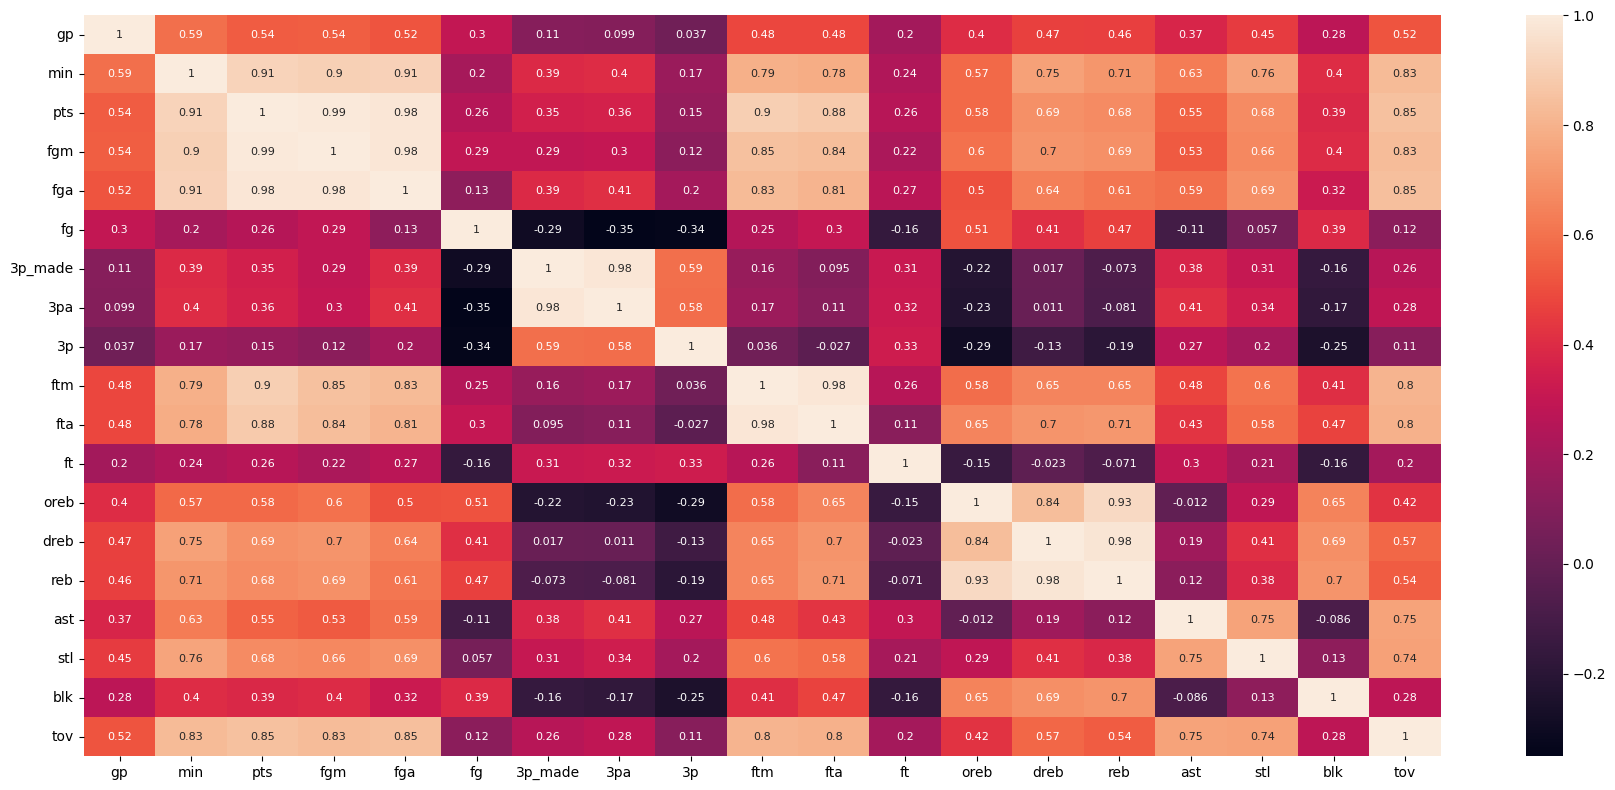

In [15]:
plt.figure(figsize = (18, 8))
sns.heatmap(data = play_corr, annot = True, annot_kws = {'size' : 8})

plt.tight_layout()
plt.show()

Several features exhibited strong multicollinearity (correlation coefficient > 0.90), including FGM, FGA, FTA, 3PA, OREB, and DREB. To reduce redundancy and improve model stability, these variables were removed while retaining more informative or aggregated features such as PTS, REB, FTM, and 3P_MADE.

In [16]:
df.drop(['fgm', 'fga', 'fta', '3pa', 'dreb', 'oreb'], axis = 1, inplace = True)

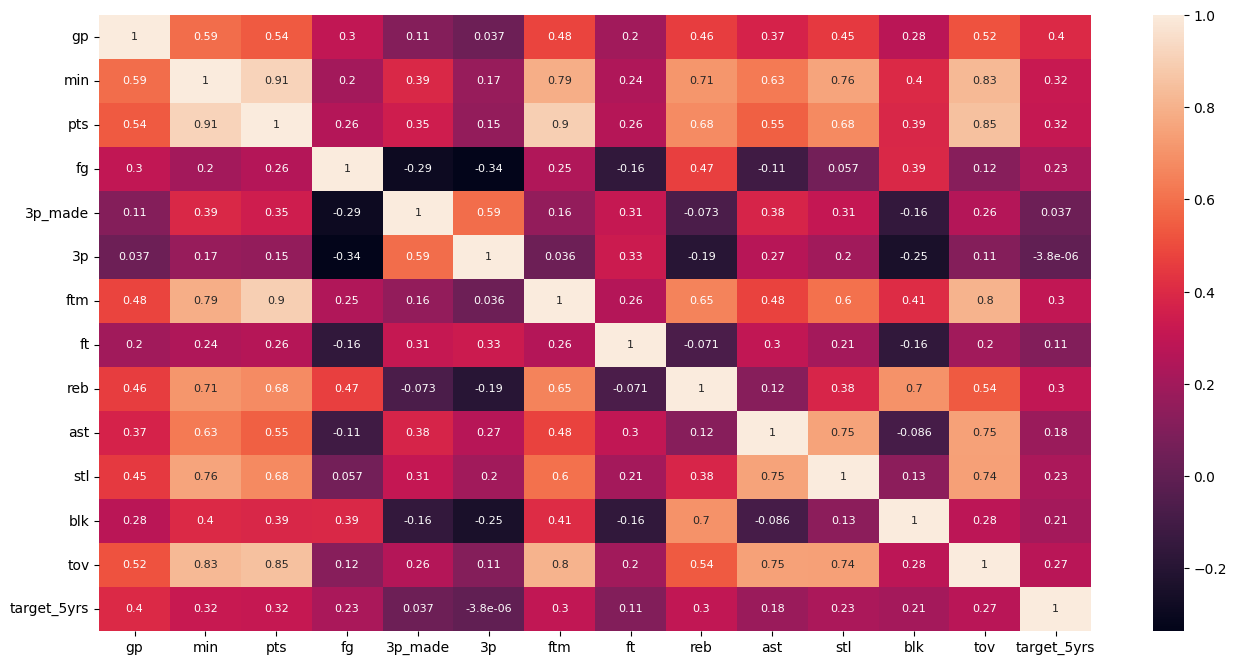

In [17]:
plt.figure(figsize = (16, 8))
sns.heatmap(df.corr(), annot = True, annot_kws = {'size' : 8})
plt.show()

In [19]:
df['points_per_min'] = df['pts'] / df['min']
df['efficiency_rating'] =  df['pts'] + df['reb'] + df['ast'] + df['stl'] + df['blk'] - df['tov']

In [20]:
df.head()

,gp,min,pts,fg,3p_made,3p,ftm,ft,reb,ast,stl,blk,tov,target_5yrs,points_per_min,efficiency_rating
0,36,27.4,7.4,34.7,0.5,25.0,1.6,69.9,4.1,1.9,0.4,0.4,1.3,0,0.270073,12.9
1,35,26.9,7.2,29.6,0.7,23.5,2.6,76.5,2.4,3.7,1.1,0.5,1.6,0,0.267658,13.3
2,74,15.3,5.2,42.2,0.4,24.4,0.9,67.0,2.2,1.0,0.5,0.3,1.0,0,0.339869,8.2
3,58,11.6,5.7,42.6,0.1,22.6,0.9,68.9,1.9,0.8,0.6,0.1,1.0,1,0.491379,8.1
4,48,11.5,4.5,52.4,0.0,0.0,1.3,67.4,2.5,0.3,0.3,0.4,0.8,1,0.391304,7.2


### Feature Engineering

To better represent player performance, several new features were engineered:

- **Points Per Minute (PPM):** Measures scoring efficiency relative to playing time.
- **Efficiency Rating:** Combines offensive and defensive contributions into a single metric.

These engineered features provide richer information for machine learning models than raw statistics alone.

In [21]:
df.isnull().sum()

,0
gp,0
min,0
pts,0
fg,0
3p_made,0
3p,0
ftm,0
ft,0
reb,0
ast,0
